# Speckles from first principles

Deep contrast is limited by residual starlight -- speckles -- not by the ideal
PSF. This notebook builds the theory of speckle generation from scratch, one
figure per step, using only physicaloptix propagation. By the end you will see
why picometers are the currency of high contrast, why one deformable mirror
digs only half a dark hole, and why quasi-static speckles are the worst noise
source in direct imaging.

Notation: pupil amplitude $A(\mathbf{u})$, wavefront error $\phi(\mathbf{u})$
in radians, focal field $E(\mathbf{x}) = \mathcal{F}[A e^{i\phi}]$.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

import equinox as eqx
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax.scipy.special import i0e
from matplotlib.colors import LogNorm

from physicaloptix import (
    Field,
    Fraunhofer,
    Grid,
    MultiScaleVortex,
    OpticalPath,
    PlaneKind,
    Stage,
    fourier_dm_basis,
)
from physicaloptix.elements import SampledOptic

WL, DIAM = 500.0, 6.0
NPUP, NFOC, PSCALE = 48, 96, 0.2  # small grids so the notebook runs in a minute
pupil = Grid.pupil(NPUP)
focal = Grid.focal(NFOC, PSCALE)
x = np.asarray(pupil.coords)
xg, yg = np.meshgrid(x, x)
aperture = ((xg**2 + yg**2) <= 0.25).astype(complex)
flat = Field(data=jnp.asarray(aperture), grid=pupil, plane=PlaneKind.PUPIL)

tele = OpticalPath(stages=(Stage("sci", Fraunhofer(grid_in=pupil, grid_out=focal)),))
airy, _ = tele.propagate(flat)
psf0 = np.abs(np.asarray(airy.data)) ** 2
PEAK, TOTAL = psf0.max(), psf0.sum()
ext = [-NFOC / 2 * PSCALE, NFOC / 2 * PSCALE] * 2

/Users/cspohn/Documents/hwo-dev/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Beat 1: a speckle is the Fourier transform of a wavefront ripple

For small errors,

$$E = \mathcal{F}[A e^{i\phi}] \approx \mathcal{F}[A] + i\,\mathcal{F}[A\phi],$$

so the focal field is the perfect PSF plus a scattered term. A single wavefront
ripple $\phi = a \cos(2\pi k u)$ scatters a **pair of speckles at
$\pm k\ \lambda/D$**: the PSF halo is the power spectrum of the wavefront
(Racine et al. 1999; Fitzgerald & Graham 2006).

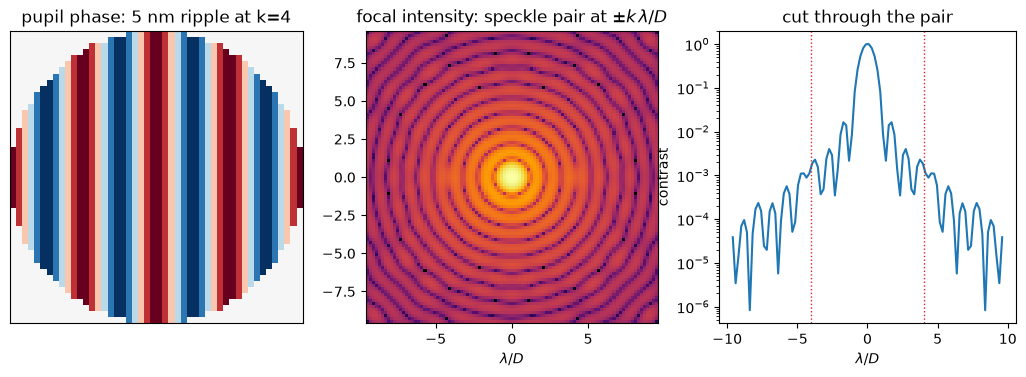

In [2]:
def ripple_field(h_nm, k, axis="x"):
    u = xg if axis == "x" else yg
    phase = 2 * np.pi * (h_nm * np.cos(2 * np.pi * k * u)) / WL
    return eqx.tree_at(
        lambda f: f.data, flat, flat.data * jnp.exp(1j * jnp.asarray(phase))
    )


h_demo, k_demo = 5.0, 4.0
out, _ = tele.propagate(ripple_field(h_demo, k_demo))
img = np.abs(np.asarray(out.data)) ** 2 / PEAK

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].imshow(
    np.angle(np.asarray(ripple_field(h_demo, k_demo).data)) * np.abs(aperture),
    origin="lower",
    cmap="RdBu_r",
)
axes[0].set_title(f"pupil phase: {h_demo:.0f} nm ripple at k={k_demo:.0f}")
axes[0].set_xticks([]), axes[0].set_yticks([])
axes[1].imshow(
    img,
    origin="lower",
    cmap="inferno",
    norm=LogNorm(1e-8, 1),
    extent=ext,
    interpolation="none",
)
axes[1].set_title(r"focal intensity: speckle pair at $\pm k\,\lambda/D$")
axes[1].set_xlabel(r"$\lambda/D$")
axes[2].semilogy(np.linspace(ext[0], ext[1], NFOC), img[NFOC // 2, :])
for s in (-k_demo, k_demo):
    axes[2].axvline(s, color="C3", ls=":", lw=1)
axes[2].set_title("cut through the pair")
axes[2].set_xlabel(r"$\lambda/D$"), axes[2].set_ylabel("contrast")
plt.show()

The spatial frequency of the wavefront error *is* the angular separation of
the speckle it makes. Higher-frequency ripples throw their speckles farther
out.

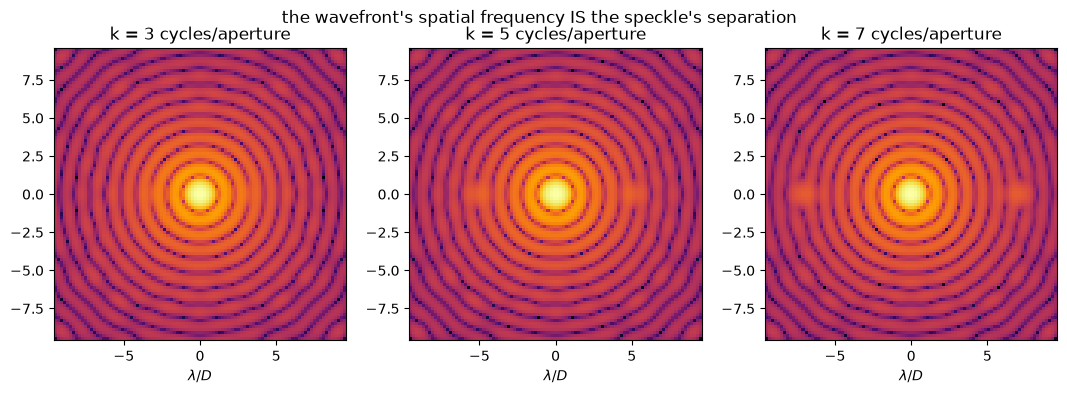

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, k in zip(axes, (3.0, 5.0, 7.0)):
    out, _ = tele.propagate(ripple_field(5.0, k))
    ax.imshow(
        np.abs(np.asarray(out.data)) ** 2 / PEAK,
        origin="lower",
        cmap="inferno",
        norm=LogNorm(1e-8, 1),
        extent=ext,
        interpolation="none",
    )
    ax.set_title(f"k = {k:.0f} cycles/aperture")
    ax.set_xlabel(r"$\lambda/D$")
fig.suptitle("the wavefront's spatial frequency IS the speckle's separation")
plt.show()

## Beat 2: the contrast currency is picometers

To first order the speckle contrast of a ripple of amplitude $h$ is

$$c \approx \left(\frac{\pi h}{\lambda}\right)^2 : \qquad
1\ \mathrm{nm} \rightarrow 4\times10^{-5}, \qquad
1\ \mathrm{pm} \rightarrow 4\times10^{-11}.$$

Earth-twin contrasts near $10^{-10}$ therefore demand picometer-class wavefront
control and knowledge (the tolerancing story for segmented apertures: Laginja
et al. 2022; the dynamic-range framing: Soummer et al. 2007). The measured scaling below holds in the small-phase limit and rolls off as the fundamental sideband saturates (the Bessel $J_1$ nonlinearity).

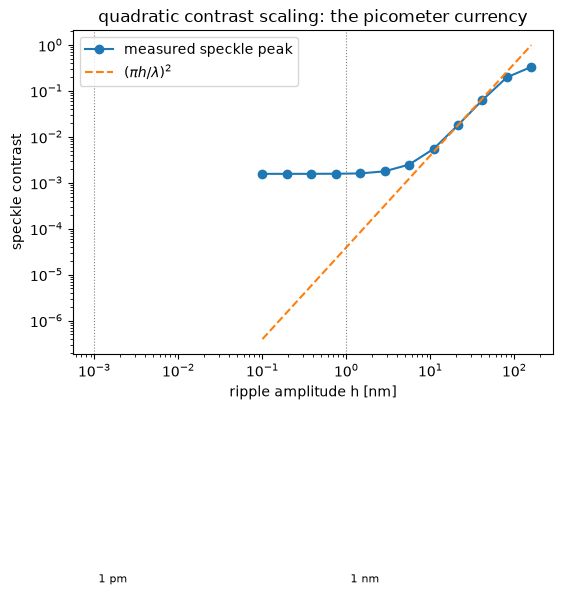

In [4]:
hs = np.logspace(-1, 2.2, 12)  # 0.1 nm .. 160 nm
peaks = []
for h in hs:
    im = np.abs(np.asarray(tele.propagate(ripple_field(h, k_demo))[0].data)) ** 2 / PEAK
    col = int(NFOC / 2 + k_demo / PSCALE)
    peaks.append(im[NFOC // 2 - 2 : NFOC // 2 + 3, col - 2 : col + 3].max())
peaks = np.array(peaks)

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.loglog(hs, peaks, "o-", label="measured speckle peak")
ax.loglog(hs, (np.pi * hs / WL) ** 2, "--", label=r"$(\pi h/\lambda)^2$")
for h_mark, lab in ((1e-3, "1 pm"), (1.0, "1 nm")):
    ax.axvline(h_mark, color="0.5", ls=":", lw=0.8)
    ax.text(h_mark, 2e-12, f" {lab}", fontsize=8)
ax.set_xlabel("ripple amplitude h [nm]"), ax.set_ylabel("speckle contrast")
ax.set_title("quadratic contrast scaling: the picometer currency")
ax.legend()
plt.show()

## Beat 2b: the coronagraph removes the core, not the speckles

A vortex nulls the perfect PSF term $\mathcal{F}[A]$; the scattered term is not nulled and survives. With a multi-mode 2 nm rms error, the same train that nulled
the core by many decades now floors at speckle contrast.

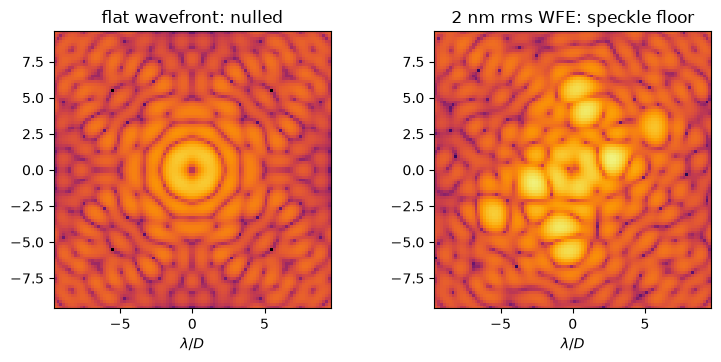

In [5]:
lyot = SampledOptic(
    transmission=jnp.asarray(((xg**2 + yg**2) <= 0.45**2).astype(float)),
    grid=pupil,
    plane=PlaneKind.PUPIL,
)
vortex = MultiScaleVortex.build(
    charge=2, npup=NPUP, q=64, scaling_factor=4, window_size=16
)
vortex_train = OpticalPath(
    stages=(
        Stage("vortex", vortex),
        Stage("lyot", lyot),
        Stage("sci", Fraunhofer(grid_in=pupil, grid_out=focal)),
    )
)

rng = np.random.default_rng(3)
opd = np.zeros_like(xg)
for k, amp, ph in zip(
    (3.0, 4.2, 5.5, 6.3), (1.2, 1.0, 0.8, 0.6), rng.uniform(0, 2 * np.pi, 4)
):
    ang = rng.uniform(0, np.pi)
    u = xg * np.cos(ang) + yg * np.sin(ang)
    opd += amp * np.cos(2 * np.pi * k * u + ph)
aberrated = eqx.tree_at(
    lambda f: f.data, flat, flat.data * jnp.exp(1j * 2 * jnp.pi * jnp.asarray(opd) / WL)
)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, fld, title in (
    (axes[0], flat, "flat wavefront: nulled"),
    (axes[1], aberrated, "2 nm rms WFE: speckle floor"),
):
    out, _ = vortex_train.propagate(fld)
    ax.imshow(
        np.abs(np.asarray(out.data)) ** 2 / PEAK,
        origin="lower",
        cmap="inferno",
        norm=LogNorm(1e-12, 1e-4),
        extent=ext,
        interpolation="none",
    )
    ax.set_title(title), ax.set_xlabel(r"$\lambda/D$")
plt.show()

## Beat 3: two quadratures, two mirrors

Phase errors scatter into the **imaginary** quadrature of the focal field; amplitude errors into the **real** quadrature. The intensities look identical -- the
difference lives in the complex field. This is why one pupil phase deformable
mirror, which writes only the phase quadrature, can null just one side of the
field, and why a full 360-degree dark hole needs a second, out-of-pupil mirror
(two-mirror stroke-minimal solutions: Pueyo et al. 2009; the field estimation
that drives them: Give'on et al. 2011).

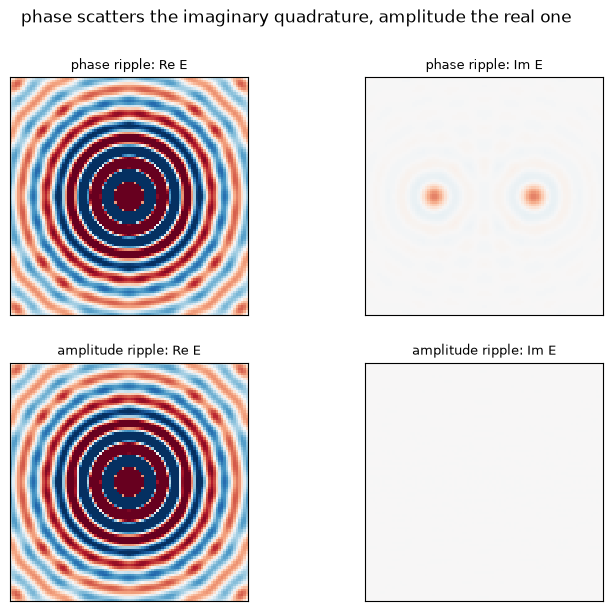

In [6]:
amp_ripple = eqx.tree_at(
    lambda f: f.data,
    flat,
    flat.data * (1.0 + 0.02 * jnp.cos(2 * jnp.pi * k_demo * jnp.asarray(xg))),
)
pha_ripple = ripple_field(1.6, k_demo)  # ~0.02 rad

fig, axes = plt.subplots(2, 2, figsize=(8.4, 6.8))
for row, (fld, nm) in enumerate(
    ((pha_ripple, "phase ripple"), (amp_ripple, "amplitude ripple"))
):
    out, _ = tele.propagate(fld)
    e = np.asarray(out.data) / np.sqrt(PEAK)
    for col, (part, pname) in enumerate(((e.real, "Re E"), (e.imag, "Im E"))):
        ax = axes[row, col]
        ax.imshow(
            part,
            origin="lower",
            cmap="RdBu_r",
            vmin=-0.02,
            vmax=0.02,
            extent=ext,
            interpolation="none",
        )
        ax.set_title(f"{nm}: {pname}", fontsize=9)
        ax.set_xticks([]), ax.set_yticks([])
fig.suptitle("phase scatters the imaginary quadrature, amplitude the real one")
plt.show()

Propagation is what couples the two quadratures: a pure phase ripple, carried a
short distance, grows a real (amplitude) component -- the Talbot effect shown
quantitatively in the [propagators tutorial](02_Propagators_and_Sampling). That
phase-to-amplitude conversion is the physical lever the out-of-pupil mirror
uses to reach the amplitude quadrature a single pupil mirror cannot touch.

## Beat 4: speckle pinning makes drift linear

Speckles are **coherent with the star**. With a static field $E_0$ and a drift
$\delta E$,

$$I = |E_0 + \delta E|^2 = |E_0|^2 + \underbrace{2\,\mathrm{Re}(E_0^* \delta E)}_{\text{pinning cross term}} + |\delta E|^2 .$$

Where $E_0$ is bright the intensity responds **linearly** to drift (pinned
speckles); in a perfect dark hole only the quadratic term survives. This
linearity is what makes dark-hole maintenance tractable (Pogorelyuk & Kasdin
2019).

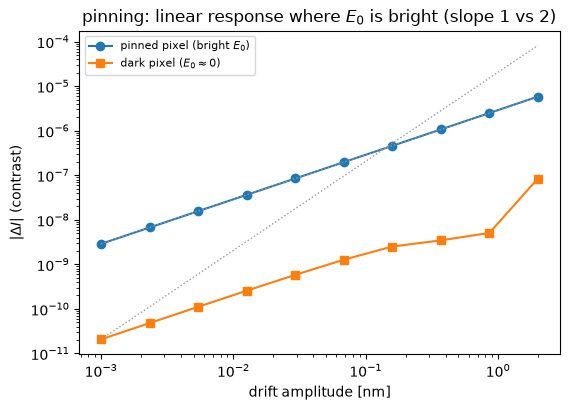

In [7]:
drift_basis = fourier_dm_basis(pupil, n_actuators=12, k_min=3.8, k_max=4.4)
n_dr = drift_basis.coeffs.shape[0]
direction = rng.standard_normal(n_dr)
direction = direction / np.linalg.norm(direction)
B_arr = np.asarray(drift_basis.B)


def drifted_intensity(eps_nm):
    opd_d = np.einsum("m,mij->ij", eps_nm * direction, B_arr)
    fld = eqx.tree_at(
        lambda f: f.data,
        aberrated,
        aberrated.data * jnp.exp(1j * 2 * jnp.pi * jnp.asarray(opd_d) / WL),
    )
    return np.abs(np.asarray(vortex_train.propagate(fld)[0].data)) ** 2 / PEAK


I0 = drifted_intensity(0.0)
bright = np.unravel_index(np.argmax(I0), I0.shape)
r_map = np.hypot(
    *np.meshgrid(np.linspace(ext[0], ext[1], NFOC), np.linspace(ext[0], ext[1], NFOC))
)
ann = (r_map > 3) & (r_map < 6)
dark = np.unravel_index(np.argmax(ann & (I0 < np.percentile(I0[ann], 5))), I0.shape)

eps_grid = np.logspace(-3, 0.3, 10)
d_bright = [abs(drifted_intensity(e)[bright] - I0[bright]) for e in eps_grid]
d_dark = [abs(drifted_intensity(e)[dark] - I0[dark]) for e in eps_grid]

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.loglog(eps_grid, d_bright, "o-", label="pinned pixel (bright $E_0$)")
ax.loglog(eps_grid, d_dark, "s-", label=r"dark pixel ($E_0 \approx 0$)")
ax.loglog(eps_grid, d_bright[0] * eps_grid / eps_grid[0], "0.6", ls=":", lw=1)
ax.loglog(eps_grid, d_dark[0] * (eps_grid / eps_grid[0]) ** 2, "0.6", ls=":", lw=1)
ax.set_xlabel("drift amplitude [nm]"), ax.set_ylabel(r"$|\Delta I|$ (contrast)")
ax.set_title("pinning: linear response where $E_0$ is bright (slope 1 vs 2)")
ax.legend(fontsize=8)
plt.show()

## Beat 5a: statistics are modified-Rician

For a static coherent field $I_c = |E_0|^2$ plus a random speckle halo of mean
$I_s$, the intensity follows the **modified Rician**

$$p(I) = \frac{1}{I_s} \exp\!\left(-\frac{I + I_c}{I_s}\right)
I_0\!\left(\frac{2\sqrt{I I_c}}{I_s}\right),$$

whose long positive tail is why speckle noise beats photon noise (Racine et al.
1999; Fitzgerald & Graham 2006; Soummer et al. 2007). We draw many random
wavefront realizations and histogram the intensity at the pinned pixel.

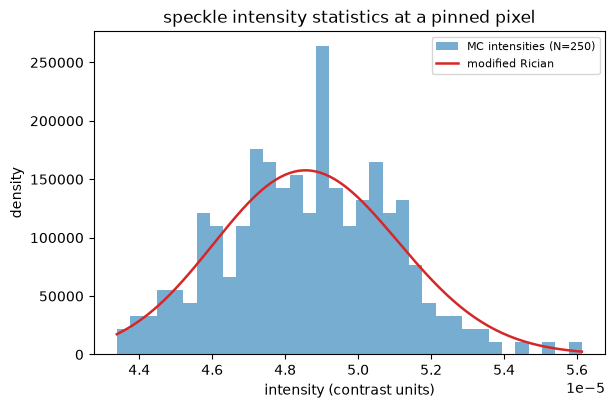

In [8]:
n_mc = 250
sigma_eps = 0.15  # nm rms per mode
eps_draws = rng.standard_normal((n_mc, n_dr)) * sigma_eps
ints_bright = []
for e in eps_draws:
    opd_d = np.einsum("m,mij->ij", e, B_arr)
    fld = eqx.tree_at(
        lambda f: f.data,
        aberrated,
        aberrated.data * jnp.exp(1j * 2 * jnp.pi * jnp.asarray(opd_d) / WL),
    )
    img = np.abs(np.asarray(vortex_train.propagate(fld)[0].data)) ** 2 / PEAK
    ints_bright.append(img[bright])
ints_bright = np.array(ints_bright)

Ic = I0[bright]
Is = max(np.mean(ints_bright) - Ic, 1e-16)
grid_I = np.linspace(ints_bright.min(), ints_bright.max(), 200)
arg = 2 * np.sqrt(grid_I * Ic) / Is
mr = (1 / Is) * np.exp(-(grid_I + Ic) / Is + arg) * np.asarray(i0e(arg))

fig, ax = plt.subplots(figsize=(6.6, 4.2))
ax.hist(
    ints_bright, bins=35, density=True, alpha=0.6, label=f"MC intensities (N={n_mc})"
)
ax.plot(grid_I, mr, "C3-", lw=1.8, label="modified Rician")
ax.set_xlabel("intensity (contrast units)"), ax.set_ylabel("density")
ax.set_title("speckle intensity statistics at a pinned pixel")
ax.legend(fontsize=8)
plt.show()

Temporally, fast speckles average as $1/\sqrt{N}$ into a smooth halo;
**quasi-static** speckles -- thermal drift and non-common-path aberrations on
minute-to-hour timescales (Vigan et al. 2022) -- do not average, and survive
differential imaging. That is why quasi-static speckle stability, not raw
contrast, limits angular differential imaging (Marois et al. 2006; LOCI:
Lafreniere et al. 2007).

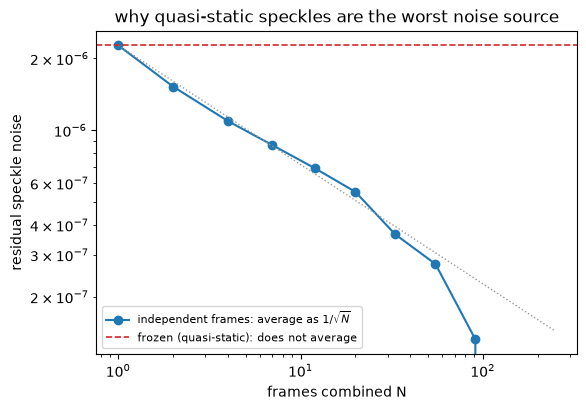

In [9]:
Ns = np.unique(np.logspace(0, np.log10(n_mc), 12).astype(int))
resid_fast = [
    np.std(ints_bright[: (n_mc // N) * N].reshape(-1, N).mean(axis=1)) for N in Ns
]

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.loglog(Ns, resid_fast, "o-", label=r"independent frames: average as $1/\sqrt{N}$")
ax.loglog(Ns, resid_fast[0] / np.sqrt(Ns), "0.6", ls=":", lw=1)
ax.axhline(
    np.std(ints_bright),
    color="C3",
    ls="--",
    lw=1.2,
    label="frozen (quasi-static): does not average",
)
ax.set_xlabel("frames combined N"), ax.set_ylabel("residual speckle noise")
ax.set_title("why quasi-static speckles are the worst noise source")
ax.legend(fontsize=8)
plt.show()

## Beat 5b: chromaticity separates speckles from planets

A wavefront ripple at $k$ cycles/aperture sits at $k\lambda/D$ **radians** --
its angular separation grows linearly with wavelength -- while a planet sits at
a fixed sky angle. Watching a source across wavelength therefore separates
speckles (which march radially) from planets (which stay put): the discriminant
an integral-field spectrograph exploits.

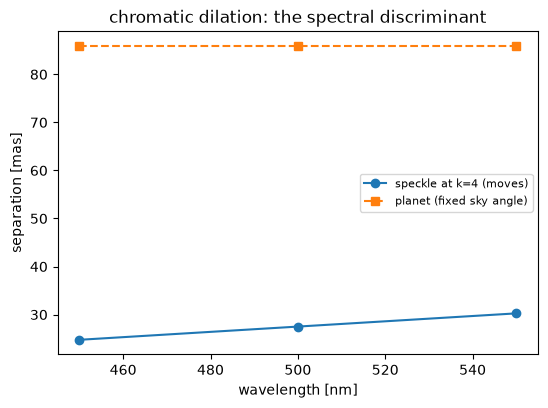

In [10]:
lams = np.array([450.0, 500.0, 550.0])
lod_mas = lams * 1e-9 / DIAM * (180 / np.pi * 3600e3)
spk_sep, planet_sep = [], []
planet_sky = 5.0 * lod_mas[1]  # fixed sky angle, mas
for lam in lams:
    phase = 2 * np.pi * (h_demo * np.cos(2 * np.pi * k_demo * xg)) / lam
    fld = eqx.tree_at(
        lambda f: f.data, flat, flat.data * jnp.exp(1j * jnp.asarray(phase))
    )
    img = np.abs(np.asarray(tele.propagate(fld)[0].data)) ** 2
    spk_px = np.argmax(img[NFOC // 2, NFOC // 2 + 5 :]) + 5
    spk_sep.append(spk_px * PSCALE * lam * 1e-9 / DIAM * (180 / np.pi * 3600e3))
    planet_sep.append(planet_sky)

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(lams, spk_sep, "o-", label=f"speckle at k={k_demo:.0f} (moves)")
ax.plot(lams, planet_sep, "s--", label="planet (fixed sky angle)")
ax.set_xlabel("wavelength [nm]"), ax.set_ylabel("separation [mas]")
ax.set_title("chromatic dilation: the spectral discriminant")
ax.legend(fontsize=8)
plt.show()

## Synthesis

- Speckles are the Fourier transform of wavefront error; contrast
  $\approx (\pi h/\lambda)^2$ makes picometers the currency.
- Phase and amplitude are separate quadratures; propagation mixes them, so one
  mirror digs half a plane and two mirrors dig 360 degrees.
- Coherence with the star pins speckles and makes their drift response linear
  -- the basis for the [speckle layer](../explanation/architecture)
  ({func}`~physicaloptix.linearize` and its `(E_nom, G)` model), which the [next
  notebook](06_The_Speckle_Layer_in_Code) drives in code and the `tiptilt`
  control library turns into a dark-hole loop.
- Statistics are modified-Rician with a heavy tail; quasi-static speckles do
  not average and set the post-processing floor.
- Time and wavelength are the discriminants post-processing exploits.

## References

- Racine et al. 1999 -- Speckle noise and the detection of faint companions.
- Fitzgerald & Graham 2006 -- Speckle statistics in adaptively corrected images.
- Marois et al. 2006 -- Angular differential imaging.
- Lafreniere et al. 2007 -- LOCI PSF subtraction.
- Soummer et al. 2007 -- Speckle noise and dynamic range in coronagraphic images.
- Pueyo et al. 2009 -- Optimal dark-hole generation via two deformable mirrors.
- Give'on et al. 2011 -- Pair-wise probing field estimation.
- Pogorelyuk & Kasdin 2019 -- Dark-hole maintenance under speckle drift.
- Laginja et al. 2022 -- Segmented-aperture wavefront tolerances at high contrast.
- Vigan et al. 2022 -- Temporal stability of non-common-path aberrations on sky.